# Bank Marketing Data Science Project

## Predicting Customer Response to Bank Marketing Campaigns

This notebook contains the complete reproducible analysis for the practical assignment.

The analytical question is:

**Can historical customer and campaign information be used to predict whether a client is likely to subscribe to a term deposit?**

Random seed used throughout: **42**


## 1. Environment and Package Versions

The following cell records the software versions required to reproduce the project.


In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import sklearn

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)


Python: 3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
pandas: 3.0.5
NumPy: 2.5.3
matplotlib: 3.11.2
scikit-learn: 1.9.1


## 2. Imports and Project Configuration


In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42

DATA_PATH = Path("../data/bank-full.csv")
CHART_DIR = Path("../charts")
CHART_DIR.mkdir(exist_ok=True)

print("Dataset path:", DATA_PATH.resolve())


Dataset path: C:\Users\nooklyweb\Desktop\bank-marketing-data-science-project\data\bank-full.csv


## 3. Load the Dataset

The dataset uses semicolons rather than commas as separators.


In [3]:
df = pd.read_csv(DATA_PATH, sep=";")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 4. Data Audit

The audit checks structure, completeness, duplicates, target distribution and categorical values.


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget counts:")
print(df["y"].value_counts())

print("\nTarget percentages:")
print((df["y"].value_counts(normalize=True) * 100).round(2))


Shape: (45211, 17)

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data types:
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Duplicate rows:


0

Target counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Target percentages:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


In [5]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))



--- job ---
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

--- marital ---
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

--- education ---
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

--- default ---
default
no     44396
yes      815
Name: count, dtype: int64

--- housing ---
housing
yes    25130
no     20081
Name: count, dtype: int64

--- loan ---
loan
no     37967
yes     7244
Name: count, dtype: int64

--- contact ---
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

--- month ---
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403

### Data-quality observations

The dataset contains no standard missing values and no duplicate rows.

However, several variables contain the category `unknown`, which represents unavailable information and must not automatically be treated as ordinary missing data.

The target is strongly imbalanced:

- approximately 88.3% did not subscribe;
- approximately 11.7% subscribed.

The variable `duration` represents the duration of the marketing call. Since this value is only known after the call takes place, it creates a potential leakage problem when the objective is to make predictions before contacting a customer.

For this reason, `duration` is excluded from the realistic predictive models.


## 5. Exploratory Data Analysis


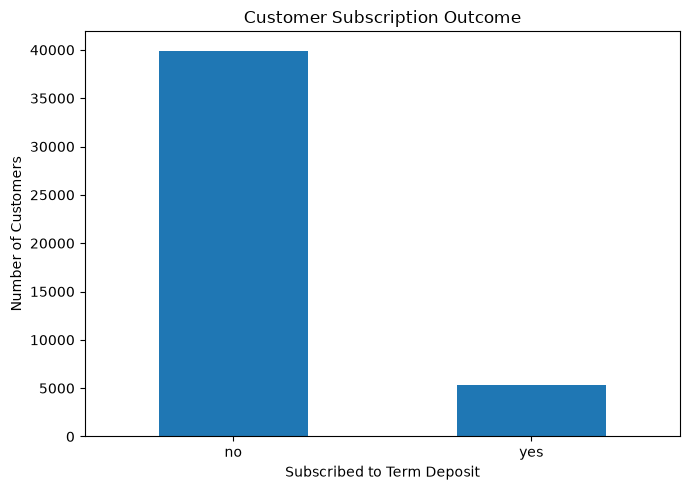

In [6]:
target_counts = df["y"].value_counts()

plt.figure(figsize=(7, 5))
target_counts.plot(kind="bar")
plt.title("Customer Subscription Outcome")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CHART_DIR / "01_target_distribution.png", dpi=200)
plt.show()


contact
cellular     14.92
telephone    13.42
unknown       4.07
Name: subscribed, dtype: float64


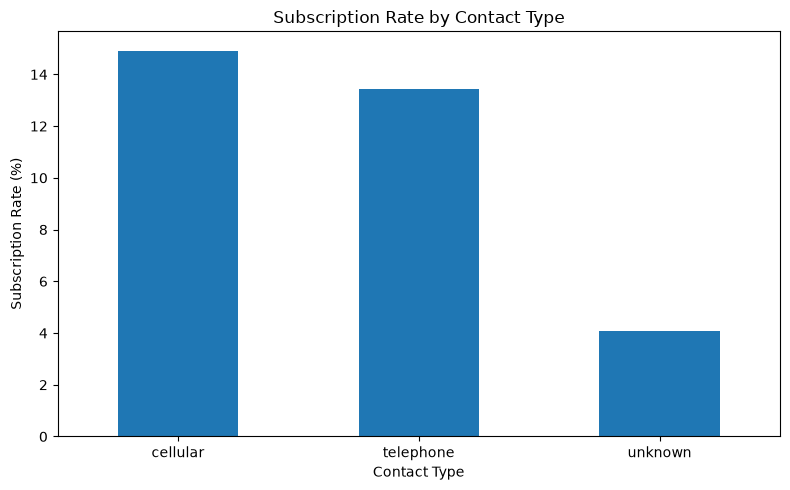

In [7]:
contact_rate = (
    df.assign(subscribed=(df["y"] == "yes").astype(int))
      .groupby("contact")["subscribed"]
      .mean()
      .sort_values(ascending=False) * 100
)

print(contact_rate.round(2))

plt.figure(figsize=(8, 5))
contact_rate.plot(kind="bar")
plt.title("Subscription Rate by Contact Type")
plt.xlabel("Contact Type")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CHART_DIR / "02_subscription_by_contact.png", dpi=200)
plt.show()


month
jan    10.12
feb    16.65
mar    51.99
apr    19.68
may     6.72
jun    10.22
jul     9.09
aug    11.01
sep    46.46
oct    43.77
nov    10.15
dec    46.73
Name: subscribed, dtype: float64


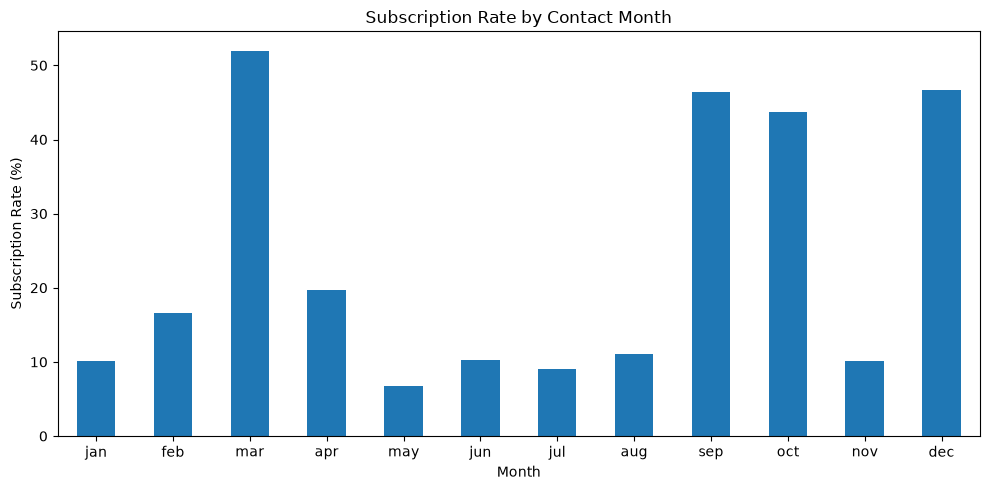

In [8]:
month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

month_rate = (
    df.assign(subscribed=(df["y"] == "yes").astype(int))
      .groupby("month")["subscribed"]
      .mean()
      .reindex(month_order) * 100
)

print(month_rate.round(2))

plt.figure(figsize=(10, 5))
month_rate.plot(kind="bar")
plt.title("Subscription Rate by Contact Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CHART_DIR / "03_subscription_by_month.png", dpi=200)
plt.show()


poutcome
success    64.73
other      16.68
failure    12.61
unknown     9.16
Name: subscribed, dtype: float64


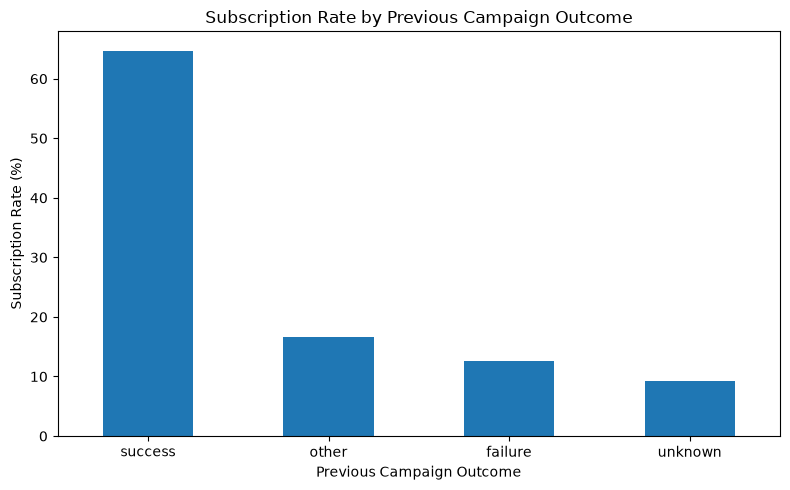

In [9]:
poutcome_rate = (
    df.assign(subscribed=(df["y"] == "yes").astype(int))
      .groupby("poutcome")["subscribed"]
      .mean()
      .sort_values(ascending=False) * 100
)

print(poutcome_rate.round(2))

plt.figure(figsize=(8, 5))
poutcome_rate.plot(kind="bar")
plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CHART_DIR / "04_subscription_by_poutcome.png", dpi=200)
plt.show()


### EDA interpretation

The exploratory analysis showed:

- strong target-class imbalance;
- higher observed subscription rates for cellular and telephone contacts than unknown contact type;
- large differences in subscription rate between months;
- and a strong relationship between previous campaign success and the current subscription outcome.

These findings support retaining `contact`, `month` and `poutcome` as candidate predictors.

The patterns are associations and should not be interpreted as proof of causation.


## 6. Prepare the Modelling Dataset

The target is converted to binary form:

- `0` = no subscription
- `1` = subscription

`duration` is deliberately removed because of leakage risk.


In [10]:
X = df.drop(columns=["y", "duration"])
y = df["y"].map({"no": 0, "yes": 1})

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)
print("Number of predictors:", X.shape[1])


Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numeric features: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Number of predictors: 15


## 7. Train/Test Split

A stratified 80/20 split is used so that the subscriber/non-subscriber proportions remain similar in both sets.

Random seed: **42**


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True).round(4))


Training set: (36168, 15)
Test set: (9043, 15)

Training distribution:
y
0    0.883
1    0.117
Name: proportion, dtype: float64

Test distribution:
y
0    0.883
1    0.117
Name: proportion, dtype: float64


## 8. Baseline Model

The baseline uses a majority-class Dummy Classifier.

This provides a simple reference point against which improved models can be evaluated.


In [12]:
baseline_preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("numeric", "passthrough", numeric_features)
])

baseline_pipeline = Pipeline([
    ("preprocessor", baseline_preprocessor),
    ("model", DummyClassifier(
        strategy="most_frequent",
        random_state=RANDOM_STATE
    ))
])

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)
baseline_prob = baseline_pipeline.predict_proba(X_test)[:, 1]

baseline_results = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred, zero_division=0),
    "Recall": recall_score(y_test, baseline_pred, zero_division=0),
    "F1": f1_score(y_test, baseline_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, baseline_prob)
}

print(baseline_results)
print("\nConfusion matrix:")
print(confusion_matrix(y_test, baseline_pred))

print("\nClassification report:")
print(classification_report(y_test, baseline_pred, zero_division=0))


{'Accuracy': 0.8830034280659074, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'ROC-AUC': 0.5}

Confusion matrix:
[[7985    0]
 [1058    0]]

Classification report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7985
           1       0.00      0.00      0.00      1058

    accuracy                           0.88      9043
   macro avg       0.44      0.50      0.47      9043
weighted avg       0.78      0.88      0.83      9043



### Baseline interpretation

The baseline achieves high raw accuracy because the dataset is imbalanced.

However, it identifies no subscribers at all.

This demonstrates why accuracy alone is not an appropriate measure of model usefulness in this project.


## 9. Improved Model 1: Balanced Logistic Regression


In [13]:
logistic_preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("numeric", StandardScaler(), numeric_features)
])

logistic_pipeline = Pipeline([
    ("preprocessor", logistic_preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

logistic_pipeline.fit(X_train, y_train)

logistic_pred = logistic_pipeline.predict(X_test)
logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

logistic_results = {
    "Accuracy": accuracy_score(y_test, logistic_pred),
    "Precision": precision_score(y_test, logistic_pred),
    "Recall": recall_score(y_test, logistic_pred),
    "F1": f1_score(y_test, logistic_pred),
    "ROC-AUC": roc_auc_score(y_test, logistic_prob)
}

print(logistic_results)
print("\nConfusion matrix:")
print(confusion_matrix(y_test, logistic_pred))

print("\nClassification report:")
print(classification_report(y_test, logistic_pred))


{'Accuracy': 0.7548379962401858, 'Precision': 0.2662363856393707, 'Recall': 0.6238185255198487, 'F1': 0.37319762510602206, 'ROC-AUC': 0.7722383533397332}

Confusion matrix:
[[6166 1819]
 [ 398  660]]

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      7985
           1       0.27      0.62      0.37      1058

    accuracy                           0.75      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.75      0.79      9043



## 10. Improved Model 2: Balanced Random Forest


In [14]:
forest_preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        categorical_features
    ),
    ("numeric", "passthrough", numeric_features)
])

forest_pipeline = Pipeline([
    ("preprocessor", forest_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

forest_pipeline.fit(X_train, y_train)

forest_pred = forest_pipeline.predict(X_test)
forest_prob = forest_pipeline.predict_proba(X_test)[:, 1]

forest_results = {
    "Accuracy": accuracy_score(y_test, forest_pred),
    "Precision": precision_score(y_test, forest_pred),
    "Recall": recall_score(y_test, forest_pred),
    "F1": f1_score(y_test, forest_pred),
    "ROC-AUC": roc_auc_score(y_test, forest_prob)
}

print(forest_results)
print("\nConfusion matrix:")
print(confusion_matrix(y_test, forest_pred))

print("\nClassification report:")
print(classification_report(y_test, forest_pred))


{'Accuracy': 0.8790224483025545, 'Precision': 0.4797297297297297, 'Recall': 0.40264650283553877, 'F1': 0.43782117163412126, 'ROC-AUC': 0.7936113672493201}

Confusion matrix:
[[7523  462]
 [ 632  426]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7985
           1       0.48      0.40      0.44      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.67      0.69      9043
weighted avg       0.87      0.88      0.87      9043



## 11. Model Comparison


In [15]:
comparison = pd.DataFrame(
    {
        "Dummy Baseline": baseline_results,
        "Logistic Regression": logistic_results,
        "Random Forest": forest_results
    }
).T

comparison.round(4)


,Accuracy,Precision,Recall,F1,ROC-AUC
Dummy Baseline,0.8830,0.0000,0.0000,0.0000,0.5000
Logistic Regression,0.7548,0.2662,0.6238,0.3732,0.7722
Random Forest,0.8790,0.4797,0.4026,0.4378,0.7936


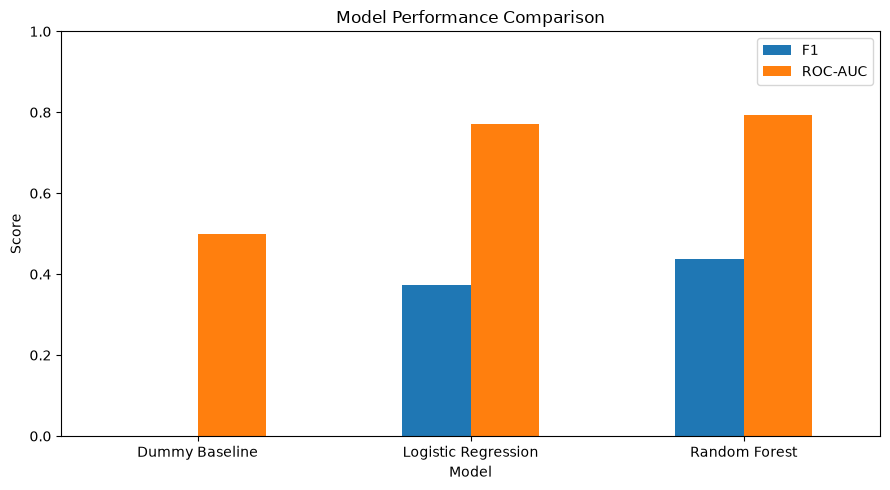

In [16]:
comparison[["F1", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CHART_DIR / "05_model_comparison.png", dpi=200)
plt.show()


## 12. Final Model Decision

Random Forest is selected as the preferred model because it provides the strongest overall balance among the models tested.

Observed test performance from the project:

- Accuracy: approximately 87.9%
- Precision: approximately 48.0%
- Recall: approximately 40.3%
- F1-score: approximately 43.8%
- ROC-AUC: approximately 0.794

Balanced Logistic Regression achieves higher recall, making it useful if the organisation's priority changes toward identifying as many potential subscribers as possible.

However, Random Forest provides a better overall F1-score and higher ROC-AUC while producing substantially fewer false-positive marketing leads.

The model should still be treated as decision support rather than an automatic customer-selection system.


## 13. Limitations

Important limitations include:

1. The project uses historical public data and may not represent current customer behaviour.
2. The dataset comes from a specific banking context and may not generalise to another organisation.
3. Class imbalance remains challenging.
4. The preferred Random Forest model still misses some subscribers.
5. Observed relationships do not prove causation.
6. Personal characteristics such as age, job and marital status require careful ethical interpretation.
7. Real deployment would require live-data testing, governance, monitoring and business validation.


## 14. Conclusion

The analysis shows that meaningful prediction is possible even after excluding the leakage-prone `duration` variable.

The majority-class baseline achieved high accuracy but had no practical ability to identify subscribers.

Both improved models provided more useful results.

Random Forest achieved the strongest overall F1-score and ROC-AUC and was therefore selected as the preferred model for this project.

The solution meets the project objective of demonstrating a manageable, reproducible data science workflow rather than attempting to create a production-ready automated decision system.
